In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from cdk.analysis.cytosol import platereader as pr

In [10]:
data, platemap = pr.load_platereader_data(
    data_file='data/20260330-123133-cytation5-pure-timecourse-gfp-MFG-196,MFG-194,MFG-193-QC-biotek-cdk.txt',
    platemap_file='data/platemap.tsv',
    platereader="biotek-cdk"
)

In [24]:
data['Time_h'] = data['Time'].dt.total_seconds()/3600

In [16]:
platemap[platemap.Type == 'Standard'].Name.value_counts(dropna=False)

Name
1 uM Fluorescein    3
Name: count, dtype: int64

In [17]:
data = pr.normalize_data_to_controls(data, '1 uM Fluorescein')

Data Normalized to 1 uM Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Text(43.41541666666666, 0.5, 'Normalized fluorescence')

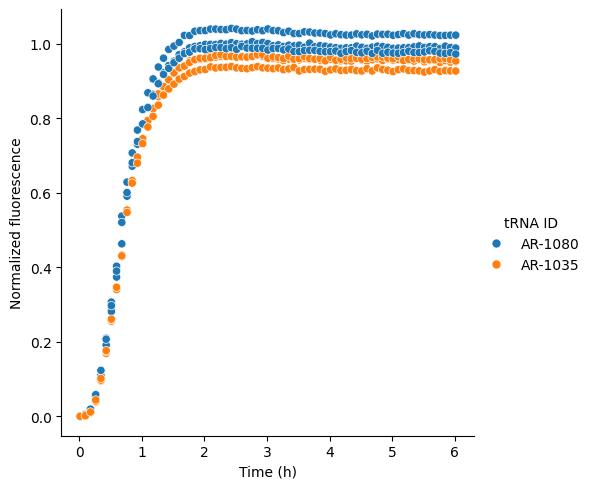

In [32]:
#| label: fig:column_facet
sns.relplot(data, x='Time_h', y='data_normalized', hue="tRNA ID")
ax = plt.gca()
ax.set_xlabel('Time (h)')
ax.set_ylabel('Normalized fluorescence')